# Pre-training ST-GCN pada Landmark MMEW

**Letak di peta:** pre-training **bukan** evaluasi akhir skripsi. Tujuannya inisialisasi backbone sebelum LOSO SMIC. Evaluasi yang dilaporkan ke penguji adalah metrik **global LOSO SMIC**, bukan akurasi 43% di MMEW (itu training-set accuracy, cenderung optimistis).

Notebook ini melatih ST-GCN pada **300 sekuens mikro** MMEW agar model mempelajari dinamika otot wajah sebelum fine-tune ke SMIC.

Arsitektur (`GraphConv`, `TemporalConv`, `STGCNBlock`, `STGCN_Model`) **identik** dengan `stgcn_smic_training.ipynb`. Perbedaan hanya pada kepala klasifikasi: MMEW punya **7 kelas**, SMIC punya 3. Saat transfer ke SMIC, muat backbone dan **lewati** `fc.weight` / `fc.bias`.

Pipeline:

1. Muat `.npy` dari `stgcn_mmew_landmarks/{kelas}/`
2. Bangun adjacency Face Mesh (468×468) yang sama dengan pipeline SMIC
3. Tensor `(T, V, C)` → `(C, T, V)` → batch `(N, C, T, V)`
4. Pre-training 25 epoch, Adam `lr=1e-3`
5. Simpan `stgcn_mmew_pretrained.pth`

> Jalankan `stgcn_mmew_extraction.ipynb` terlebih dahulu agar folder landmark terisi.


In [1]:
# =============================================================================
# 1. IMPORT, KONFIGURASI, DAN DETEKSI DEVICE
# =============================================================================
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

import mediapipe as mp

# ==========================================
# KONFIGURASI EKSEKUSI (Lokal vs Server)
# ==========================================
RUN_ON_SERVER = False  # Ubah ke True jika dijalankan di server GPU berkapasitas tinggi

if RUN_ON_SERVER:
    CFG = {
        "epochs": 150,
        "batch_size": 32,
        "use_augmentation": True,
        "patience": 20,
        "num_workers": 4
    }
else:
    CFG = {
        "epochs": 2,
        "batch_size": 4,
        "use_augmentation": False,
        "patience": 2,
        "num_workers": 0
    }

print(f"Mode eksekusi : {'SERVER' if RUN_ON_SERVER else 'LOKAL'}")
print(f"CFG           : {CFG}")

# Landmark MMEW hasil ekstraksi (folder stgcn/)
LANDMARK_ROOT = Path('stgcn_mmew_landmarks').resolve()
CHECKPOINT_PATH = Path('stgcn_mmew_pretrained.pth').resolve()

NUM_FRAMES = 16
NUM_NODES = 468
NUM_CHANNELS = 3
NOSE_INDEX = 1

# Samakan dengan SMIC: wajah MMEW sudah di-crop, Pose Normalization dimatikan.
# Ablasi SMIC: Pose Normalization justru menurunkan Macro F1 karena wajah sudah registrasi.
# MMEW juga crop 231×231, jadi saklar ini disamakan False agar distribusi fitur mirip saat transfer.
USE_POSE_NORMALIZATION = False

# Nilai di bawah ini mengikuti CFG (LOKAL vs SERVER) agar satu saklar mengatur seluruh training.
BATCH_SIZE = CFG["batch_size"]
NUM_WORKERS = CFG["num_workers"]
NUM_EPOCHS = CFG["epochs"]
USE_AUGMENTATION = CFG["use_augmentation"]
RANDOM_SEED = 42
# Adam lr=1e-3: training from scratch (bukan fine-tune ImageNet). LR 1e-4 terlalu lambat di sini.
LEARNING_RATE = 1e-3

# 7 kelas MMEW Micro_Expression — urutan folder, mapping tetap 0..6
LABEL_TO_INDEX = {
    'anger': 0,
    'disgust': 1,
    'fear': 2,
    'happiness': 3,
    'others': 4,
    'sadness': 5,
    'surprise': 6,
}
INDEX_TO_LABEL = {idx: name for name, idx in LABEL_TO_INDEX.items()}
num_classes = len(LABEL_TO_INDEX)

if not LANDMARK_ROOT.is_dir():
    raise FileNotFoundError(
        f'Folder landmark MMEW tidak ditemukan: {LANDMARK_ROOT}\n'
        'Jalankan stgcn_mmew_extraction.ipynb terlebih dahulu.'
    )

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f'Device yang digunakan: {device}')
print(f'Landmark root : {LANDMARK_ROOT}')
print(f'Checkpoint    : {CHECKPOINT_PATH}')
print(f'Dimensi data  : (C={NUM_CHANNELS}, T={NUM_FRAMES}, V={NUM_NODES})')
print(f'Jumlah kelas  : {num_classes} -> {LABEL_TO_INDEX}')


/opt/anaconda3/envs/microsense/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device yang digunakan: mps
Landmark root : /Users/stefanieagahari/Micro-Expression-Detector/python test/stgcn/stgcn_mmew_landmarks
Checkpoint    : /Users/stefanieagahari/Micro-Expression-Detector/python test/stgcn/stgcn_mmew_pretrained.pth
Dimensi data  : (C=3, T=16, V=468)
Jumlah kelas  : 7 -> {'anger': 0, 'disgust': 1, 'fear': 2, 'happiness': 3, 'others': 4, 'sadness': 5, 'surprise': 6}


## 2. Adjacency Matrix Face Mesh

Matriks graf **sama persis** dengan notebook SMIC agar bobot spasial kompatibel saat transfer.
**Mengapa adjacency harus identik dengan SMIC?** GraphConv melakukan `A_hat @ fitur`. Jika edge Face Mesh berbeda, bobot spasial yang ditransfer tidak punya arti geometris yang sama.


In [2]:
# =============================================================================
# 2. BANGUN DAN NORMALISASI ADJACENCY MATRIX (468 x 468)
# =============================================================================
def build_adjacency_matrix(num_nodes: int = NUM_NODES) -> np.ndarray:
    """Bangun adjacency matrix simetris dari FACEMESH_TESSELATION."""
    connections = mp.solutions.face_mesh.FACEMESH_TESSELATION
    adjacency = np.zeros((num_nodes, num_nodes), dtype=np.float32)
    for source, target in connections:
        if source >= num_nodes or target >= num_nodes:
            continue
        adjacency[source, target] = 1.0
        adjacency[target, source] = 1.0
    return adjacency


def normalize_adjacency(adjacency: np.ndarray) -> np.ndarray:
    """Symmetric normalized adjacency: A_hat = D^(-1/2) (A + I) D^(-1/2)."""
    num_nodes = adjacency.shape[0]
    # A_tilde = A + I : self-loop. Tanpa I, node hanya agregasi tetangga dan kehilangan koordinatnya sendiri.
    adjacency_tilde = adjacency + np.eye(num_nodes, dtype=np.float32)
    degree = adjacency_tilde.sum(axis=1)
    degree_inv_sqrt = np.power(degree, -0.5, where=degree > 0)
    degree_inv_sqrt[degree == 0] = 0.0
    degree_matrix_inv_sqrt = np.diag(degree_inv_sqrt).astype(np.float32)
    return degree_matrix_inv_sqrt @ adjacency_tilde @ degree_matrix_inv_sqrt


adjacency_raw = build_adjacency_matrix(NUM_NODES)
adjacency_normalized = normalize_adjacency(adjacency_raw)
A = torch.from_numpy(adjacency_normalized).to(device)

print(f'Shape adjacency        : {tuple(A.shape)}')
print(f'Total edge (unik)      : {int(adjacency_raw.sum() // 2)}')
print(f'Device matriks A       : {A.device}')


Shape adjacency        : (468, 468)
Total edge (unik)      : 1322
Device matriks A       : mps:0


## 3. Dataset Landmark MMEW

Satu file `.npy` = satu klip `(16, 468, 3)`. Label diambil dari nama folder kelas, lalu dipetakan ke integer 0–6. Transpose ke `(C, T, V)` mengikuti format ST-GCN SMIC.
**Format ST-GCN:** `.npy` = `(T, V, C)`. Model mengharapkan `(C, T, V)` agar `Conv2d` melihat peta **waktu × node**, analog gambar **tinggi × lebar**.


In [3]:
# =============================================================================
# 3. DATASET MMEW: .npy PER KELAS → TENSOR (C, T, V)
# =============================================================================
class MMEWGraphDataset(Dataset):
    """Dataset graf MMEW mikro: satu .npy = satu sekuens."""

    def __init__(
        self,
        root_dir: str | Path,
        label_to_index: dict = LABEL_TO_INDEX,
        nose_index: int = NOSE_INDEX,
        pose_normalization: bool = USE_POSE_NORMALIZATION,
        augment: bool = False,
    ):
        self.root_dir = Path(root_dir)
        self.label_to_index = label_to_index
        self.nose_index = nose_index
        self.pose_normalization = pose_normalization
        self.augment = augment

        self.samples = []
        for class_name, class_index in sorted(label_to_index.items(), key=lambda kv: kv[1]):
            class_dir = self.root_dir / class_name
            if not class_dir.is_dir():
                continue
            for npy_path in sorted(class_dir.glob('*.npy')):
                self.samples.append((npy_path, class_index))

        if not self.samples:
            raise FileNotFoundError(
                f'Tidak ada file .npy di {self.root_dir}. '
                'Jalankan stgcn_mmew_extraction.ipynb terlebih dahulu.'
            )

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, index: int):
        npy_path, label = self.samples[index]
        landmarks = np.load(npy_path).astype(np.float32)
        tensor = torch.from_numpy(landmarks)

        if self.pose_normalization:
            nose_coords = tensor[:, self.nose_index:self.nose_index + 1, :]
            tensor = tensor - nose_coords

        # (T, V, C) → (C, T, V)
        # permute(2,0,1): (T,V,C) → (C,T,V). contiguous() wajib setelah permute agar view/batchnorm aman.
        tensor = tensor.permute(2, 0, 1).contiguous()
        if self.augment:
            tensor = tensor + 0.01 * torch.randn_like(tensor)
        return tensor, label


graph_dataset = MMEWGraphDataset(LANDMARK_ROOT, augment=USE_AUGMENTATION)
labels_all = [label for _, label in graph_dataset.samples]

print(f'Total sampel graf: {len(graph_dataset)}')
print(f'Pose Normalization: {"AKTIF" if USE_POSE_NORMALIZATION else "NONAKTIF"}')
print('Distribusi kelas:')
print(
    pd.Series([INDEX_TO_LABEL[label] for label in labels_all])
    .value_counts()
    .reindex(list(LABEL_TO_INDEX.keys()))
)

train_loader = DataLoader(
    graph_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,   # pre-training memakai SEMUA 300 klip; shuffle meratakan urutan kelas yang tidak seimbang
    num_workers=NUM_WORKERS,
    persistent_workers=NUM_WORKERS > 0,
)

sample_tensor, sample_label = graph_dataset[0]
inputs, labels = next(iter(train_loader))
print(f'\nContoh sampel ke-0 : {tuple(sample_tensor.shape)}  (C, T, V)')
print(f'Label sampel ke-0  : {sample_label} ({INDEX_TO_LABEL[sample_label]})')
print(f'Batch DataLoader   : {tuple(inputs.shape)}  (N, C, T, V)')
print(f'Batch size         : {BATCH_SIZE} | shuffle=True')


Total sampel graf: 300
Pose Normalization: NONAKTIF
Distribusi kelas:
anger         8
disgust      72
fear         16
happiness    36
others       66
sadness      13
surprise     89
Name: count, dtype: int64

Contoh sampel ke-0 : (3, 16, 468)  (C, T, V)
Label sampel ke-0  : 0 (anger)
Batch DataLoader   : (16, 3, 16, 468)  (N, C, T, V)
Batch size         : 16 | shuffle=True


## 4. Arsitektur ST-GCN

Salinan langsung dari `stgcn_smic_training.ipynb`. Kepala `fc` mengeluarkan 7 logit (kelas MMEW).
**Baca tensor `(N, C, T, V)`:** `N` batch, `C=3` koordinat, `T=16` waktu, `V=468` node. `GraphConv` = `A_hat @ fitur @ W` (agregasi tetangga). `TemporalConv` kernel `(9, 1)` menyapu 9 frame tanpa mencampur node. Residual menjaga gradien pada 3 blok bertumpuk.


In [4]:
# =============================================================================
# 4. DEFINISI ARSITEKTUR ST-GCN (IDENTIK DENGAN PIPELINE SMIC)
# =============================================================================
class GraphConv(nn.Module):
    """Graph Convolution spasial: f_out = A_hat @ f_in @ W."""

    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.transform = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x: torch.Tensor, adjacency: torch.Tensor) -> torch.Tensor:
        # Conv2d 1×1 = f_in @ W: tiap node diproyeksikan channel-wise tanpa mencampur tetangga.
        x = self.transform(x)
        # einsum: A_hat @ fitur. 'nctv,vw->nctw' menjumlahkan tetangga v ke tujuan w.
        # Inilah Graph Convolution: informasi mengalir di sepanjang edge Face Mesh.
        x = torch.einsum('nctv,vw->nctw', x, adjacency)
        return x.contiguous()


class TemporalConv(nn.Module):
    """Konvolusi temporal: menyapu dimensi waktu T dengan kernel (K_t, 1)."""

    def __init__(self, in_channels: int, out_channels: int, kernel_size: int = 9):
        super().__init__()
        # Padding simetris di T agar panjang waktu tetap 16. Padding V = 0: node tidak boleh tercampur di sini.
        padding = ((kernel_size - 1) // 2, 0)
        self.conv = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=(kernel_size, 1),
            padding=padding,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.conv(x)


class STGCNBlock(nn.Module):
    """Satu blok ST-GCN: Spatial (GraphConv) diikuti Temporal (TemporalConv)."""

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        temporal_kernel: int = 9,
        dropout: float = 0.3,
    ):
        super().__init__()
        self.graph_conv = GraphConv(in_channels, out_channels)
        self.batch_norm_spatial = nn.BatchNorm2d(out_channels)
        self.temporal_conv = TemporalConv(out_channels, out_channels, temporal_kernel)
        self.batch_norm_temporal = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(dropout)

        if in_channels == out_channels:
            self.residual = nn.Identity()
        else:
            self.residual = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x: torch.Tensor, adjacency: torch.Tensor) -> torch.Tensor:
        identity = self.residual(x)
        out = self.graph_conv(x, adjacency)
        out = self.relu(self.batch_norm_spatial(out))
        out = self.temporal_conv(out)
        out = self.batch_norm_temporal(out)
        out = self.dropout(out)
        return self.relu(out + identity)


class STGCN_Model(nn.Module):
    """ST-GCN sederhana: 3 blok spatio-temporal + global pooling + FC."""

    def __init__(
        self,
        in_channels: int = NUM_CHANNELS,
        num_classes: int = num_classes,
        num_nodes: int = NUM_NODES,
    ):
        super().__init__()
        self.data_batch_norm = nn.BatchNorm1d(in_channels * num_nodes)
        self.block1 = STGCNBlock(in_channels, 64)
        self.block2 = STGCNBlock(64, 64)
        self.block3 = STGCNBlock(64, 128)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x: torch.Tensor, adjacency: torch.Tensor) -> torch.Tensor:
        batch_size, channels, num_frames, num_nodes = x.shape
        x = x.permute(0, 1, 3, 2).contiguous()
        x = x.view(batch_size, channels * num_nodes, num_frames)
        x = self.data_batch_norm(x)
        x = x.view(batch_size, channels, num_nodes, num_frames)
        x = x.permute(0, 1, 3, 2).contiguous()

        x = self.block1(x, adjacency)
        x = self.block2(x, adjacency)
        x = self.block3(x, adjacency)
        # Global Average Pooling (T, V) → vektor 128-D per klip. fc lalu memetakan ke 7 logit MMEW.
        x = x.mean(dim=(2, 3))
        return self.fc(x)


model = STGCN_Model().to(device)
model.eval()
with torch.no_grad():
    dummy = torch.zeros(2, NUM_CHANNELS, NUM_FRAMES, NUM_NODES, device=device)
    dummy_out = model(dummy, A)

total_params = sum(p.numel() for p in model.parameters())
print(f'Sanity check input  : {tuple(dummy.shape)}  (N, C, T, V)')
print(f'Sanity check output : {tuple(dummy_out.shape)}  (harus (2, {num_classes}))')
print(f'Total parameter     : {total_params:,}')


Sanity check input  : (2, 3, 16, 468)  (N, C, T, V)
Sanity check output : (2, 7)  (harus (2, 7))
Total parameter     : 247,871


## 5. Loop Pre-training

Seluruh 300 klip MMEW dipakai sebagai data latih (bukan LOSO). Adam `lr=1e-3`, `CrossEntropyLoss`, 25 epoch. Loss dan Accuracy dicetak tiap epoch.
**Adam vs SGD:** Adam menyesuaikan learning rate per-parameter. Cocok saat skala koordinat landmark dan bobot GraphConv berbeda. `weight_decay=1e-4` adalah L2 ringan agar 300 sampel tidak mudah menghafal.

**CrossEntropyLoss:** klasifikasi 7 kelas. Logit `fc` berukuran 7; softmax implisit di dalam loss (jangan softmax manual sebelum loss).


In [5]:
# =============================================================================
# 5. PRE-TRAINING LOOP PADA MMEW
# =============================================================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
# CFG['patience'] dipakai di sini: turunkan LR jika loss stagnan (pre-train tidak punya val fold).
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=CFG['patience'],
)

history = {'loss': [], 'accuracy': []}

print(f'Loss      : CrossEntropyLoss')
print(f'Optimizer : Adam (lr={LEARNING_RATE}, weight_decay=1e-4)')
print(f'Scheduler : ReduceLROnPlateau (mode=min, patience={CFG["patience"]})')
print(f'Epoch     : {NUM_EPOCHS}')
print(f'Augmentasi: {"AKTIF" if USE_AUGMENTATION else "NONAKTIF"}')
print(f'Sampel    : {len(graph_dataset)} klip mikro MMEW')
print('=' * 72)

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    running_loss = 0.0
    n_correct = 0
    n_samples = 0

    for graphs, batch_labels in train_loader:
        graphs = graphs.to(device)
        batch_labels = batch_labels.to(device)

        # Nolkan gradien dulu: PyTorch mengakumulasi gradien antar batch jika lupa zero_grad.
        optimizer.zero_grad()
        # A (adjacency) sama untuk semua batch — topologi wajah tidak berubah antar subjek.
        outputs = model(graphs, A)
        loss = criterion(outputs, batch_labels)
        loss.backward()
        optimizer.step()

        batch_n = graphs.size(0)
        running_loss += loss.item() * batch_n
        preds = outputs.argmax(dim=1)
        n_correct += (preds == batch_labels).sum().item()
        n_samples += batch_n

    epoch_loss = running_loss / n_samples
    epoch_acc = n_correct / n_samples
    history['loss'].append(epoch_loss)
    history['accuracy'].append(epoch_acc)
    scheduler.step(epoch_loss)

    print(
        f'Epoch {epoch:02d}/{NUM_EPOCHS}  |  '
        f'Loss: {epoch_loss:.4f}  |  '
        f'Accuracy: {epoch_acc * 100:.2f}%'
    )

print('=' * 72)
print(f'Loss akhir     : {history["loss"][-1]:.4f}')
print(f'Accuracy akhir : {history["accuracy"][-1] * 100:.2f}%')


Loss      : CrossEntropyLoss
Optimizer : Adam (lr=0.001, weight_decay=1e-4)
Epoch     : 25
Sampel    : 300 klip mikro MMEW


Epoch 01/25  |  Loss: 1.8335  |  Accuracy: 26.33%


Epoch 02/25  |  Loss: 1.6372  |  Accuracy: 35.67%


Epoch 03/25  |  Loss: 1.6097  |  Accuracy: 34.67%


Epoch 04/25  |  Loss: 1.6137  |  Accuracy: 31.67%


...

Epoch 21/25  |  Loss: 1.5226  |  Accuracy: 38.00%


Epoch 22/25  |  Loss: 1.5352  |  Accuracy: 40.33%


Epoch 23/25  |  Loss: 1.5345  |  Accuracy: 39.67%


Epoch 24/25  |  Loss: 1.4906  |  Accuracy: 42.00%


Epoch 25/25  |  Loss: 1.4458  |  Accuracy: 43.00%
Loss akhir     : 1.4458
Accuracy akhir : 43.00%


## 6. Simpan Bobot Pre-trained

File `stgcn_mmew_pretrained.pth` berisi `state_dict`. Saat fine-tune SMIC (3 kelas), muat dengan `strict=False` atau buang kunci `fc.*` karena ukuran kepala klasifikasi berbeda.
**Transfer ke SMIC:** jangan `load_state_dict` utuh. `fc.weight` MMEW adalah `(7, 128)`, SMIC `(3, 128)`. PyTorch **tetap error** walau `strict=False` jika kunci yang sama ukurannya beda. Solusi: buang kunci `fc.*`, lalu `strict=False` untuk sisa backbone.


Checkpoint tersimpan : /Users/stefanieagahari/Micro-Expression-Detector/python test/stgcn/stgcn_mmew_pretrained.pth
Jumlah kunci         : 63

Cara memuat ke pipeline SMIC (3 kelas):
  pretrained = torch.load("stgcn_mmew_pretrained.pth", map_location=device)
  pretrained = {k: v for k, v in pretrained.items() if not k.startswith("fc.")}
  model.load_state_dict(pretrained, strict=False)


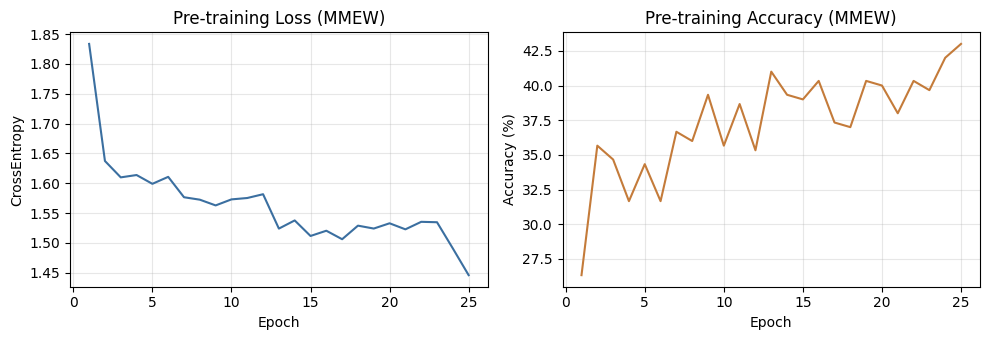

In [6]:
# =============================================================================
# 6. SIMPAN STATE_DICT UNTUK TRANSFER KE SMIC
# =============================================================================
# Hanya state_dict (bukan model utuh) agar arsitektur SMIC 3 kelas bisa memuat backbone ini nanti.
torch.save(model.state_dict(), CHECKPOINT_PATH)

print(f'Checkpoint tersimpan : {CHECKPOINT_PATH}')
print(f'Jumlah kunci         : {len(model.state_dict())}')
print('\nCara memuat ke pipeline SMIC (3 kelas):')
print('  pretrained = torch.load("stgcn_mmew_pretrained.pth", map_location=device)')
print('  pretrained = {k: v for k, v in pretrained.items() if not k.startswith("fc.")}')
print('  model.load_state_dict(pretrained, strict=False)')

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(range(1, NUM_EPOCHS + 1), history['loss'], color='#3b6fa0')
axes[0].set_title('Pre-training Loss (MMEW)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('CrossEntropy')
axes[0].grid(alpha=0.3)

axes[1].plot(range(1, NUM_EPOCHS + 1), [a * 100 for a in history['accuracy']], color='#c47b3a')
axes[1].set_title('Pre-training Accuracy (MMEW)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()
